In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv('bank-additional-full.csv', delimiter=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
# Rename target variable to a more descriptive name

df['term_deposit_subscribed'] = df['y']
df = df.drop(columns=['y']) 


In [4]:
# Rename variable for a housing loan to be more descriptive

df['has_housing_loan'] = df['housing']
df = df.drop(columns=['housing']) 

In [5]:
# Rename variable for a personal loan to be more descriptive

df['has_personal_loan'] = df['loan']
df = df.drop(columns=['loan']) 

In [6]:
# Rename variable for in default to be more descriptive

df['in_default'] = df['default']
df = df.drop(columns=['default'])

In [7]:
# Rename variable pdays to be more descriptive

df['days_since_prev_campaign_contact'] = df['pdays']
df = df.drop(columns=['pdays'])

In [8]:
# Rename variable poutcome to be more descriptive

df['previous_campaign_result'] = df['poutcome']
df = df.drop(columns=['poutcome'])

In [9]:
# Rename variable emp.var.rate to be more descriptive

df['employment_variation_rate'] = df['emp.var.rate']
df = df.drop(columns=['emp.var.rate'])

In [10]:
# Rename variable cons.price.idx to be more descriptive

df['consumer_price_index'] = df['cons.price.idx']
df = df.drop(columns=['cons.price.idx'])

In [11]:
# Rename variable cons.conf.idx to be more descriptive

df['consumer_confidence_index'] = df['cons.conf.idx']
df = df.drop(columns=['cons.conf.idx'])

In [12]:
# Rename variable euribor3m to be more descriptive

df['euribor_3mo_rate'] = df['euribor3m']
df = df.drop(columns=['euribor3m'])

In [13]:
# Rename variable marital to be more descriptive

df['marital_status'] = df['marital']
df = df.drop(columns=['marital'])

In [14]:
# Rename variable education to be more descriptive

df['education_level'] = df['education']
df = df.drop(columns=['education'])

In [15]:
# Rename variable previous to be more descriptive

df['previous_contacted'] = df['previous']
df = df.drop(columns=['previous'])

In [16]:
# Rename variable contact to be more descriptive

df['communication_type'] = df['contact']
df = df.drop(columns=['contact'])

In [17]:
# Rename variable month to be more descriptive

df['last_contact_month'] = df['month']
df = df.drop(columns=['month'])

In [18]:
# Rename variable duration to be more descriptive

df['last_contact_duration_sec'] = df['duration']
df = df.drop(columns=['duration'])

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               41188 non-null  int64  
 1   job                               41188 non-null  object 
 2   day_of_week                       41188 non-null  object 
 3   campaign                          41188 non-null  int64  
 4   nr.employed                       41188 non-null  float64
 5   term_deposit_subscribed           41188 non-null  object 
 6   has_housing_loan                  41188 non-null  object 
 7   has_personal_loan                 41188 non-null  object 
 8   in_default                        41188 non-null  object 
 9   days_since_prev_campaign_contact  41188 non-null  int64  
 10  previous_campaign_result          41188 non-null  object 
 11  employment_variation_rate         41188 non-null  float64
 12  cons

In [20]:
# Replace values that indicate no data with Nan

df['days_since_prev_campaign_contact'] = df['days_since_prev_campaign_contact'].replace(999, np.nan)
df['previous_campaign_result'] = df['previous_campaign_result'].replace('nonexistent', np.nan)

In [21]:
# Value Counts for target column

df['term_deposit_subscribed'].value_counts()

term_deposit_subscribed
no     36548
yes     4640
Name: count, dtype: int64

In [22]:
# Map the target column to binary

df['term_deposit_subscribed'] = df['term_deposit_subscribed'].map({'yes': 1, 'no': 0})

In [23]:
for col in df.select_dtypes('object').columns:
    if 'unknown' in df[col].str.lower().values:
        print(col, df[col].value_counts())

job job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
has_housing_loan has_housing_loan
yes        21576
no         18622
unknown      990
Name: count, dtype: int64
has_personal_loan has_personal_loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64
in_default in_default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64
marital_status marital_status
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64
education_level education_level
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illi

In [24]:
# Print the percent of unknown vlaues in each column

for col in df.select_dtypes('object').columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count} unknowns ({unknown_count/len(df)*100:.1f}%)")

job: 330 unknowns (0.8%)
has_housing_loan: 990 unknowns (2.4%)
has_personal_loan: 990 unknowns (2.4%)
in_default: 8597 unknowns (20.9%)
marital_status: 80 unknowns (0.2%)
education_level: 1731 unknowns (4.2%)


In [25]:
# Save the cleaned df for later use before further processing specific to clustering

# df.to_csv('Cleaned_data_1.csv')

In [26]:
# Drop small percentage unknowns

df = df[df['job'] != 'unknown']          # 330 rows (0.8%)
df = df[df['marital_status'] != 'unknown']  # 80 rows (0.2%)

In [27]:
# Check for a potential overlap in unknowns for has_loan columns

mask = (df['has_housing_loan'] == 'unknown') & (df['has_personal_loan'] == 'unknown')
print(mask.sum())

984


In [28]:
# Most Unknowns in has_home_loan and has_personal_loan overlap, this will drop 984 overlap and 6 non overlap

df = df[df['has_housing_loan'] != 'unknown']
df = df[df['has_personal_loan'] != 'unknown']

In [29]:
# Imputing the unknowns to the mode in education column

df['education_level'] = df.groupby('job')['education_level'].transform(
    lambda x: x.replace('unknown', x[x != 'unknown'].mode()[0])
)

In [30]:
# Create column for default status where known 

df['default_status_known'] = (df['in_default'] != 'unknown').astype(int)
# leave 'unknown' as a category in in_default itself

In [31]:
# Create a column where default status is not unknown and rename the old one

df['default_status_known'] = (df['in_default'] != 'unknown').astype(int)
df = df.rename(columns={'in_default': 'default_status'})

In [32]:
df.head()

,age,job,day_of_week,campaign,nr.employed,term_deposit_subscribed,has_housing_loan,has_personal_loan,default_status,days_since_prev_campaign_contact,...,consumer_price_index,consumer_confidence_index,euribor_3mo_rate,marital_status,education_level,previous_contacted,communication_type,last_contact_month,last_contact_duration_sec,default_status_known
0,56,housemaid,mon,1,5191.0,0,no,no,no,NaN,...,93.994,-36.4,4.857,married,basic.4y,0,telephone,may,261,1
1,57,services,mon,1,5191.0,0,no,no,unknown,NaN,...,93.994,-36.4,4.857,married,high.school,0,telephone,may,149,0
2,37,services,mon,1,5191.0,0,yes,no,no,NaN,...,93.994,-36.4,4.857,married,high.school,0,telephone,may,226,1
3,40,admin.,mon,1,5191.0,0,no,no,no,NaN,...,93.994,-36.4,4.857,married,basic.6y,0,telephone,may,151,1
4,56,services,mon,1,5191.0,0,no,yes,no,NaN,...,93.994,-36.4,4.857,married,high.school,0,telephone,may,307,1


In [33]:
# Prints critical info about the data so far

print(df.info())
print(df.shape)
print(df.isnull().sum())

for col in df.select_dtypes('object').columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count} unknowns")

print(df[['default_status', 'default_status_known']].value_counts())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 39803 entries, 0 to 41187
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               39803 non-null  int64  
 1   job                               39803 non-null  object 
 2   day_of_week                       39803 non-null  object 
 3   campaign                          39803 non-null  int64  
 4   nr.employed                       39803 non-null  float64
 5   term_deposit_subscribed           39803 non-null  int64  
 6   has_housing_loan                  39803 non-null  object 
 7   has_personal_loan                 39803 non-null  object 
 8   default_status                    39803 non-null  object 
 9   days_since_prev_campaign_contact  1456 non-null   float64
 10  previous_campaign_result          5431 non-null   object 
 11  employment_variation_rate         39803 non-null  float64
 12  consumer_

In [34]:
# Rename the nr.employed column

df = df.rename(columns={'nr.employed': 'num_employees'})

In [35]:
# change column to check if customer was contacted at all because of sparsity

df['was_previously_contacted'] = df['days_since_prev_campaign_contact'].notna().astype(int)

In [36]:
# Check value counts for new column

df['was_previously_contacted'].value_counts()

was_previously_contacted
0    38347
1     1456
Name: count, dtype: int64

In [37]:
# Drop old column because of lack of signal due to sparsity

df = df.drop(columns='days_since_prev_campaign_contact')

In [38]:
# Print count of values of 0 in this column

print((df['last_contact_duration_sec'] == 0).sum())

4


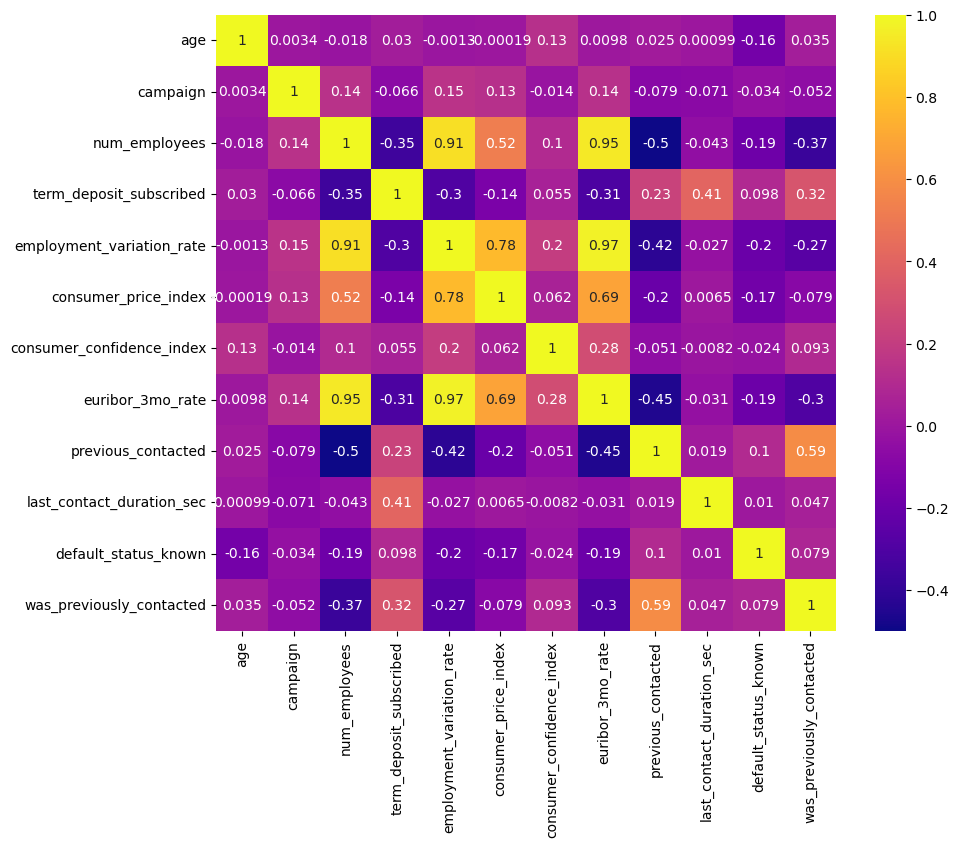

In [40]:
# Checking for high correlations for potential data leakage

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8)) 
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='plasma')
plt.show()

In [ ]:
# change column to check for positive campaing result because of sparsity

df['positive_campaign_result'] = df['previous_campaign_result'].notna().astype(int)

# Check value counts for new column

df['positive_campaign_result'].value_counts()

positive_campaign_result
0    34372
1     5431
Name: count, dtype: int64

In [ ]:
# Drop old column because of lack of signal due to sparsity

df = df.drop(columns='previous_campaign_result')

In [ ]:
# Prints critical info about the data so far

print(df.info())
print(df.shape)
print(df.isnull().sum())

for col in df.select_dtypes('object').columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count} unknowns")

print(df[['default_status', 'default_status_known']].value_counts())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 39803 entries, 0 to 41187
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        39803 non-null  int64  
 1   job                        39803 non-null  object 
 2   day_of_week                39803 non-null  object 
 3   campaign                   39803 non-null  int64  
 4   num_employees              39803 non-null  float64
 5   term_deposit_subscribed    39803 non-null  int64  
 6   has_housing_loan           39803 non-null  object 
 7   has_personal_loan          39803 non-null  object 
 8   default_status             39803 non-null  object 
 9   employment_variation_rate  39803 non-null  float64
 10  consumer_price_index       39803 non-null  float64
 11  consumer_confidence_index  39803 non-null  float64
 12  euribor_3mo_rate           39803 non-null  float64
 13  marital_status             39803 non-null  object 


In [ ]:
# Drop columns because of multicolinearity risk


df = df.drop(columns=['employment_variation_rate', 'num_employees', 'consumer_price_index'])

In [ ]:
# Save cleaned data for clustering

# df.to_csv('data_cleaned_for_clustering.csv')